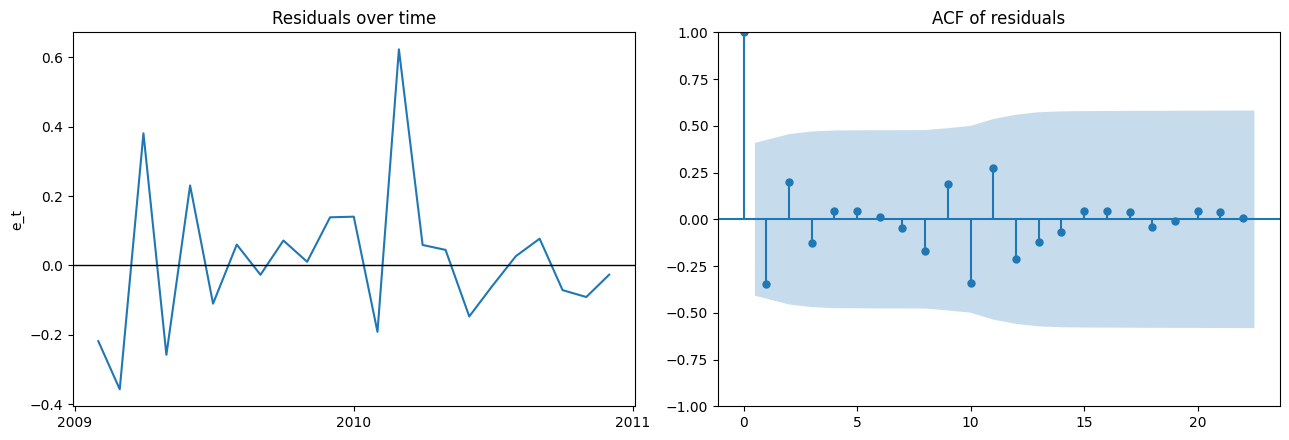

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf

# Load data
base_dir = Path.cwd()
file_path = base_dir / "datasolar.csv"
if not file_path.exists():
    file_path = base_dir / "Assignment3" / "datasolar.csv"

df = pd.read_csv(file_path)
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df.sort_values("date").set_index("date")

# Build residuals from the given model
mu = 5.72
X = np.log(df["power"].astype(float)) - mu
X_hat = 0.38 * X.shift(1) + 0.94 * X.shift(12) - 0.3572 * X.shift(13)
resid = (X - X_hat).dropna()

# Plot only: residual line plot and ACF side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(resid.index, resid.values, color="tab:blue", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals over time")
axes[0].set_ylabel("e_t")
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plot_acf(resid, lags=min(24, len(resid) - 1), ax=axes[1])
axes[1].set_title("ACF of residuals")

plt.tight_layout()
plt.show()

In [3]:
# Portmanteau lack-of-fit test
from scipy.stats import chi2
from statsmodels.tsa.stattools import acf

resid = resid.dropna().astype(float)
n = len(resid)
m = 23
model_df = 3  # estimated parameters in the fitted model

if n < 3 or resid.nunique() < 2:
    print("Portmanteau test not applicable: residuals are too short or have no variation.")
elif m <= model_df:
    print(f"Portmanteau test not applicable with only {m} lags and {model_df} estimated parameters.")
else:
    acf_values = acf(resid.to_numpy(), nlags=m, fft=False)[1:]
    acf_values = np.nan_to_num(acf_values, nan=0.0)
    Q = n * np.sum(np.array(acf_values) ** 2)
    df = m - model_df
    p_value = 1 - chi2.cdf(Q, df=df)
    print(f"Portmanteau Q statistic (m={m}): {Q:.2f}, df={df}, p-value: {p_value:.4f}")
    
Conclusion = "With a p-value above the significance levels (0.05), we fail to reject the null hypothesis of no autocorrelation in the residuals.\nSo the one step ahead residuals have no significant autocorrelation."
print(Conclusion)

Portmanteau Q statistic (m=23): 11.82, df=20, p-value: 0.9222
With a p-value above the significance levels (0.05), we fail to reject the null hypothesis of no autocorrelation in the residuals.
So the one step ahead residuals have no significant autocorrelation.


In [4]:
# Sign-changing test (runs test using residual signs)
signs = np.sign(resid.values)
signs = signs[signs != 0]  # remove exact zeros

n = len(signs)
n_pos = int((signs > 0).sum())
n_neg = int((signs < 0).sum())

if n < 2 or n_pos == 0 or n_neg == 0:
    print("Sign-changing test not applicable (insufficient sign variation).")
else:
    runs = 1 + np.sum(signs[1:] != signs[:-1])
    expected_runs = (2 * n_pos * n_neg) / n + 1
    var_runs = (2 * n_pos * n_neg * (2 * n_pos * n_neg - n)) / (n**2 * (n - 1))
    z = (runs - expected_runs) / np.sqrt(var_runs)
    p_value = 2 * (1 - norm.cdf(abs(z)))

    print(f"n={n}, n_pos={n_pos}, n_neg={n_neg}")
    print(f"Observed runs: {runs}")
    print(f"Expected runs under randomness: {expected_runs:.3f}")
    print(f"Z statistic: {z:.3f}")
    print(f"Two-sided p-value: {p_value:.4f}")

    if p_value > 0.05:
        print("Conclusion (5%): sign changes are consistent with randomness.")
    else:
        print("Conclusion (5%): sign changes are not random (possible dependence).")

n=23, n_pos=12, n_neg=11
Observed runs: 13
Expected runs under randomness: 12.478
Z statistic: 0.223
Two-sided p-value: 0.8234
Conclusion (5%): sign changes are consistent with randomness.


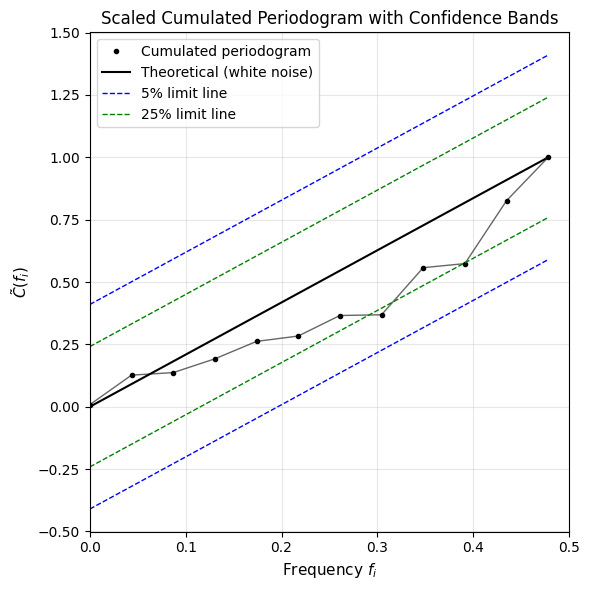

Number of observations: 23
Number of frequencies: 12
Nyquist frequency (max shown): 0.5

Confidence band distances from theoretical line:
  5% level: ±0.4101
  25% level: ±0.2412


In [5]:
# The cumulated periodogram
from scipy import signal

# Compute the periodogram using Fourier transform
N = len(resid)
residual_values = resid.values

# Calculate FFT
fft_values = np.fft.fft(residual_values)
# Only use positive frequencies
freqs = np.fft.fftfreq(N)[:(N//2 + 1)]
fft_magnitude = np.abs(fft_values[:(N//2 + 1)]) ** 2

# Periodogram: I(ν_i) = (1/N) * |FFT|²
periodogram = fft_magnitude / N

# Scaled cumulative periodogram: C̃(ν_j) = sum(I(1:j)) / sum(I(1:N/2))
cumsum_periodogram = np.cumsum(periodogram)
normalized_cumsum = cumsum_periodogram / cumsum_periodogram[-1]

# Calculate confidence bands (Kolmogorov-Smirnov type)
# For significance levels α, distance from theoretical line is K_α / sqrt(q)
# where q = (N-2)/2 for N even, q = (N-1)/2 for N odd
q = (N - 2) / 2 if N % 2 == 0 else (N - 1) / 2

# Critical values for different significance levels (from KS test)
K_05 = 1.36  # 5% level
K_25 = 0.80  # 25% level

# Theoretical line (diagonal from 0 to 1)
theoretical_line = np.linspace(0, 1, len(normalized_cumsum))

# Upper and lower confidence bounds
upper_05 = theoretical_line + K_05 / np.sqrt(q)
lower_05 = theoretical_line - K_05 / np.sqrt(q)
upper_25 = theoretical_line + K_25 / np.sqrt(q)
lower_25 = theoretical_line - K_25 / np.sqrt(q)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the cumulated periodogram as dots with connecting lines
ax.plot(freqs, normalized_cumsum, 'k-', linewidth=1, alpha=0.6)
ax.plot(freqs, normalized_cumsum, 'ko', markersize=3, label='Cumulated periodogram')

# Plot the theoretical line (solid) and confidence bands (dashed)
ax.plot(freqs, theoretical_line, 'k-', linewidth=1.5, label='Theoretical (white noise)')
ax.plot(freqs, upper_05, 'b--', linewidth=1, label='5% limit line')
ax.plot(freqs, lower_05, 'b--', linewidth=1)
ax.plot(freqs, upper_25, 'g--', linewidth=1, label='25% limit line')
ax.plot(freqs, lower_25, 'g--', linewidth=1)

ax.set_xlabel('Frequency $f_i$', fontsize=11)
ax.set_ylabel('$\~{C}(f_i)$', fontsize=11)
ax.set_title('Scaled Cumulated Periodogram with Confidence Bands', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

# Print summary
print(f"Number of observations: {N}")
print(f"Number of frequencies: {len(freqs)}")
print(f"Nyquist frequency (max shown): 0.5")
print(f"\nConfidence band distances from theoretical line:")
print(f"  5% level: ±{K_05/np.sqrt(q):.4f}")
print(f"  25% level: ±{K_25/np.sqrt(q):.4f}")


# Model predictions


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load monthly power series (36 observations)
df = pd.read_csv("datasolar.csv")
y = df["power"].to_numpy(dtype=float)
z = np.log(y)

# Model implied by:
# eps_{t+1|t} = log(Y_{t+1}) - 0.38 log(Y_t) - 0.94 log(Y_{t-11}) + 0.3572 log(Y_{t-12}) - 0.2126
# Set E[eps_{t+k}|I_t] = 0 for forecasts
phi_1 = 0.38
Phi_1 = 0.94
phiPhi_1 = 0.3572
const = 0.2126

h = 12
n = len(z)
z_ext = list(z.copy())

# Recursive forecasts on log scale for t=36, k=1,...,12
for k in range(1, h + 1):
    zhat = (
        phi_1 * z_ext[n + k - 2]
        + Phi_1 * z_ext[n + k - 13]
        - phiPhi_1 * z_ext[n + k - 14]
        + const
    )
    z_ext.append(zhat)

z_forecast = np.array(z_ext[n : n + h])
y_forecast = np.exp(z_forecast)

# Build forecast table with calendar labels
obs_dates = pd.to_datetime(
    {
        "year": df["year"].astype(int),
        "month": df["month"].astype(int),
        "day": 1,
    }
)
fc_dates = pd.date_range(start=obs_dates.iloc[-1] + pd.offsets.MonthBegin(1), periods=h, freq="MS")

forecast_table = pd.DataFrame(
    {
        "k": np.arange(1, h + 1),
        "period": fc_dates.strftime("%Y-%m"),
        "log_forecast": z_forecast,
        "Yhat_MWh": y_forecast,
    }
)

forecast_table["log_forecast"] = forecast_table["log_forecast"].round(6)
forecast_table["Yhat_MWh"] = forecast_table["Yhat_MWh"].round(3)
forecast_table


,k,period,log_forecast,Yhat_MWh
0,1,2011-01,4.617687,101.260
1,2,2011-02,4.991712,147.188
2,3,2011-03,5.055472,156.879
3,4,2011-04,4.959403,142.509
4,5,2011-05,5.872696,355.205
5,6,2011-06,6.287599,537.860
6,7,2011-07,6.415137,611.024
7,8,2011-08,6.448424,631.706
8,9,2011-09,6.445598,629.923
9,10,2011-10,6.230493,508.006


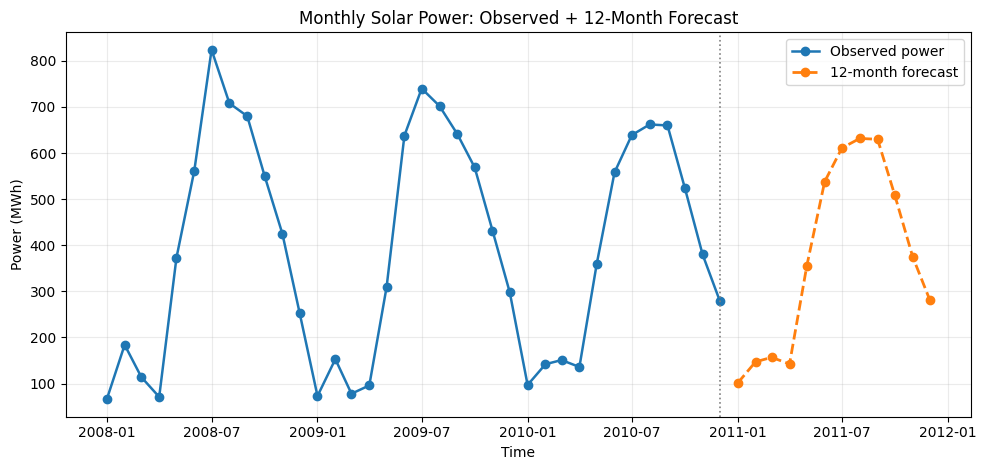

In [18]:
# Plot observed series and extension by forecasts (back-transformed power)
obs_ts = pd.Series(y, index=obs_dates)
fc_ts = pd.Series(y_forecast, index=fc_dates)

plt.figure(figsize=(10, 4.8))
plt.plot(obs_ts.index, obs_ts.values, marker="o", lw=1.8, label="Observed power")
plt.plot(fc_ts.index, fc_ts.values, marker="o", lw=2.0, ls="--", label="12-month forecast")
plt.axvline(obs_ts.index[-1], color="gray", lw=1.2, ls=":")
plt.title("Monthly Solar Power: Observed + 12-Month Forecast")
plt.xlabel("Time")
plt.ylabel("Power (MWh)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

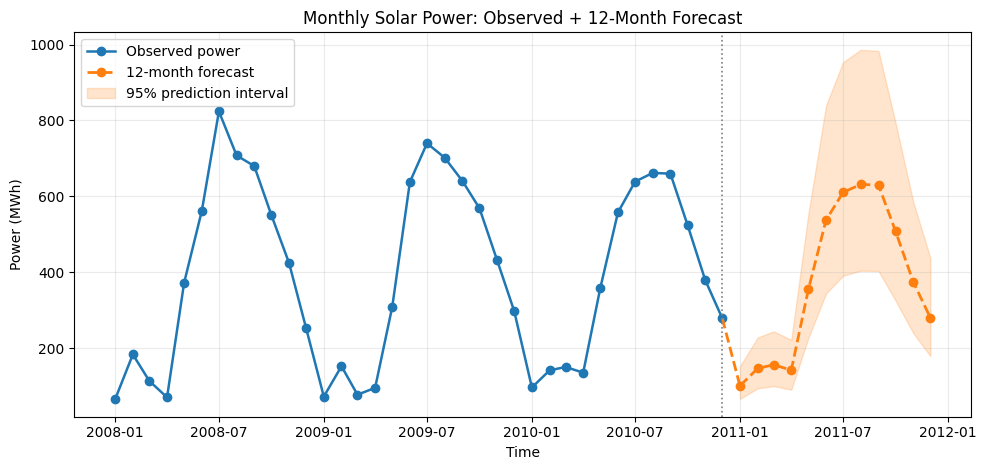

Estimated innovation std on log scale: 0.2102


In [25]:
# Seasonal-model-consistent 95% PI on log scale, then back-transform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Data
df_pred = pd.read_csv("datasolar.csv")
y_obs = df_pred["power"].to_numpy(dtype=float)
z_obs = np.log(y_obs)

# Model coefficients from the assignment equation
phi_1 = 0.38
Phi_1 = 0.94
phiPhi_1 = 0.3572
const = 0.2126

# Forecast horizon
h = 12
n = len(z_obs)

# Mean forecasts on log scale using the SAME seasonal model as your prediction cell
z_ext = list(z_obs.copy())
for k in range(1, h + 1):
    zhat = (
        phi_1 * z_ext[n + k - 2]
        + Phi_1 * z_ext[n + k - 13]
        - phiPhi_1 * z_ext[n + k - 14]
        + const
    )
    z_ext.append(zhat)
z_hat = np.array(z_ext[n : n + h])

# Estimate innovation variance from one-step residuals of the same model
z_series = pd.Series(z_obs)
z_hat_in_sample = (
    phi_1 * z_series.shift(1)
    + Phi_1 * z_series.shift(12)
    - phiPhi_1 * z_series.shift(13)
    + const
)
eps_hat = (z_series - z_hat_in_sample).dropna().to_numpy()
sigma_eps = float(np.std(eps_hat, ddof=1))

# Build psi-weights for AR polynomial:
# (1 - 0.38B - 0.94B^12 + 0.3572B^13) z_t = c + eps_t
psi = np.zeros(h)
psi[0] = 1.0
for j in range(1, h):
    val = 0.0
    if j - 1 >= 0:
        val += phi_1 * psi[j - 1]
    if j - 12 >= 0:
        val += Phi_1 * psi[j - 12]
    if j - 13 >= 0:
        val -= phiPhi_1 * psi[j - 13]
    psi[j] = val

# Forecast error std at horizon k: sqrt(sigma_eps^2 * sum_{i=0}^{k-1} psi_i^2)
sigma_k = np.sqrt((sigma_eps**2) * np.cumsum(psi**2))

# 95% PI on log scale
alpha = 0.05
z_alpha2 = norm.ppf(1 - alpha / 2)
z_low = z_hat - z_alpha2 * sigma_k
z_up = z_hat + z_alpha2 * sigma_k

# Back-transform to original scale
y_hat = np.exp(z_hat)
y_low = np.exp(z_low)
y_up = np.exp(z_up)

# Calendar index
obs_dates = pd.to_datetime(
    {
        "year": df_pred["year"].astype(int),
        "month": df_pred["month"].astype(int),
        "day": 1,
    }
)
fc_dates = pd.date_range(start=obs_dates.iloc[-1] + pd.offsets.MonthBegin(1), periods=h, freq="MS")

# Table
forecast_table_pi = pd.DataFrame(
    {
        "k": np.arange(1, h + 1),
        "period": fc_dates.strftime("%Y-%m"),
        "log_forecast": z_hat,
        "sigma_k": sigma_k,
        "log_low_95": z_low,
        "log_up_95": z_up,
        "Yhat_MWh": y_hat,
        "Ylow_95_MWh": y_low,
        "Yup_95_MWh": y_up,
    }
)
for c in ["log_forecast", "sigma_k", "log_low_95", "log_up_95"]:
    forecast_table_pi[c] = forecast_table_pi[c].round(6)
for c in ["Yhat_MWh", "Ylow_95_MWh", "Yup_95_MWh"]:
    forecast_table_pi[c] = forecast_table_pi[c].round(3)
#display(forecast_table_pi)

# Plot with same visual structure as the prediction-only figure
obs_ts = pd.Series(y_obs, index=obs_dates)
fc_ts = pd.Series(y_hat, index=fc_dates)
low_ts = pd.Series(y_low, index=fc_dates)
up_ts = pd.Series(y_up, index=fc_dates)

plt.figure(figsize=(10, 4.8))
plt.plot(obs_ts.index, obs_ts.values, marker="o", lw=1.8, label="Observed power", color="tab:blue")
plt.plot(
    [obs_ts.index[-1], fc_ts.index[0]],
    [obs_ts.values[-1], fc_ts.values[0]],
    lw=2.0,
    ls="--",
    color="tab:orange",
)
plt.plot(fc_ts.index, fc_ts.values, marker="o", lw=2.0, ls="--", label="12-month forecast", color="tab:orange")
plt.fill_between(fc_ts.index, low_ts.values, up_ts.values, color="tab:orange", alpha=0.2, label="95% prediction interval")
plt.axvline(obs_ts.index[-1], color="gray", lw=1.2, ls=":")
plt.title("Monthly Solar Power: Observed + 12-Month Forecast")
plt.xlabel("Time")
plt.ylabel("Power (MWh)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Estimated innovation std on log scale: {sigma_eps:.4f}")